# [Video RAG] VectorDB Indexing

In [1]:
%pip install -Uqqq langchain langchain-openai langchain-pinecone langchain-text-splitters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.6/587.6 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.3/259.3 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.8 MB/s eta 0:00:00


In [2]:
# 구글 드라이브 마운트 및 연동
from google.colab import drive # Colab 에서 구글 드라이브 사용 모듈
drive.mount('/content/drive') # 현재 런타임에서 내 구글드라이브 마운트(연동)

BASE_PATH = '/content/drive/MyDrive/34기/05_multimodal_rag'

Mounted at /content/drive


In [3]:
from google.colab import userdata
import os

os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = userdata.get('LANGSMITH_API_KEY')
os.environ['PINECONE_API_KEY'] = userdata.get('PINECONE_API_KEY')

## 비디오별 caption 불러오기
- BASE_PATH/captions/{video_name}_frames.csv

In [5]:
captions_dir_path = os.path.join(BASE_PATH, 'captions') # captions 폴더 경로
# captions 폴더 내 파일들을 전체 경로 리스트로 변환
csv_files_path = [os.path.join(captions_dir_path, f) for f in os.listdir(captions_dir_path)]
csv_files_path


['/content/drive/MyDrive/34기/05_multimodal_rag/captions/alpinist_frames.csv',
 '/content/drive/MyDrive/34기/05_multimodal_rag/captions/skiing_frames.csv',
 '/content/drive/MyDrive/34기/05_multimodal_rag/captions/baseball_frames.csv',
 '/content/drive/MyDrive/34기/05_multimodal_rag/captions/basketball_frames.csv',
 '/content/drive/MyDrive/34기/05_multimodal_rag/captions/soccer_frames.csv']

In [6]:
# 여러 캡션 CSV 로드 후 하나의 DataFrame 으로 병합
import pandas as pd

dfs = []  # 각 CSV 에서 읽은 DataFrames 리스트
for f in csv_files_path:
    df = pd.read_csv(f) # CSV -> DataFrame 로드
    print(f"{os.path.basename(f)} : {df.shape = }")
    dfs.append(df)

# 모든 DataFrame 을 행 방향으로 합침 (인덱스 재부여)
all_df = pd.concat(dfs, ignore_index=True)
print(all_df.shape)
all_df.head(20)

alpinist_frames.csv : df.shape = (23, 4)
skiing_frames.csv : df.shape = (12, 4)
baseball_frames.csv : df.shape = (25, 4)
basketball_frames.csv : df.shape = (14, 4)
soccer_frames.csv : df.shape = (12, 4)
(86, 4)


,id,video_filename,frame_no,description
0,21a5fd97-0b23-4695-94f3-27049ab66120,alpinist.mp4,0,"한 등산객이 주황색 패딩과 배낭을 착용하고, 스틱을 짚으며 눈 덮인 가파른 산길을 ..."
1,aff62599-62d0-445a-80ee-a0df6877873d,alpinist.mp4,30,주황색 재킷을 입은 등산객이 스틱과 아이젠을 사용해 눈 덮인 가파른 산길을 오르고 ...
2,313c33ce-0bf7-4814-ae29-0eb15b1c245b,alpinist.mp4,60,"주황색 재킷을 입은 등산객이 배낭과 스틱을 갖추고, 눈으로 덮인 가파른 산길을 오르..."
3,3f27ba42-5de5-4400-9a06-83fb721491d4,alpinist.mp4,90,"한 등산객이 주황색 패딩과 배낭을 착용하고, 스틱을 짚으며 눈 덮인 가파른 산길을 ..."
4,a414893a-9d4f-4b09-be36-699b29a4d61b,alpinist.mp4,120,눈 덮인 험준한 산길에서 한 등산객이 크램폰과 트레킹 폴을 사용해 바위와 눈 사이의...
5,4090c9d2-34fb-4e93-824f-ec95247ae034,alpinist.mp4,150,"한 등산객이 아이젠과 스틱을 착용하고, 눈 덮인 험준한 산비탈을 따라 암벽 옆 좁은..."
6,e47e449a-a5ff-4c29-9f65-d40dd6580b13,alpinist.mp4,180,"한 등산객이 주황색 재킷과 아이젠을 착용하고, 등산 스틱을 짚으며 눈 덮인 바위산 ..."
7,07e5ddec-0933-4771-9098-c986e301159b,alpinist.mp4,210,"한 등산객이 주황색 재킷과 등산 장비를 착용하고, 스틱을 짚으며 눈과 바위가 뒤섞인..."
8,c0811e06-0b97-444d-931e-25d26fd43e5c,alpinist.mp4,240,한 등산객이 주황색 재킷과 배낭을 착용하고 스틱을 이용해 눈 덮인 바위 능선을 오르...
9,f700ddc9-b717-4fd2-ab03-6fe87b1c4c49,alpinist.mp4,270,등산객이 아이젠과 스틱을 착용한 채 눈 덮인 험준한 산길을 오르고 있다. 오른쪽에는...


## chunking

In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter # Langchain 청크 분할기
from tqdm import tqdm
import uuid # 고유ID 생성

# tiktoken 기준(모델 토큰화 방식)으로 분할기 객체 생성
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    model_name = 'gpt-5.6-luna', # 토큰 인코딩 기준 모델
    chunk_size = 300,            # 청크 목표 토큰 수
    chunk_overlap = 150,         # 청크 겹치는 토큰 수
    separators = ['\n\n', '\n', ' ', ''] # 분리 우선순위 (문단 -> 줄 -> 공백 -> 문자 단위)
)


In [8]:
# 프레임 캡션 텍스트를 청크로 분할해서 DataFrame 생성
chunks = [] # 분할된 청크들을 (dict) 형태로 누적할 리스트

for idx, row in tqdm(all_df.iterrows(), total=len(all_df)):
    frame_no = row['frame_no']
    video_filename = row['video_filename']
    description = row['description']

    # 여러 청크로 분할하여 청크 단위로 순회
    for chunk in text_splitter.split_text(description):
        chunks.append(
            {
                'id': str(uuid.uuid4()), # 고유 ID 생성
                'frame_no': frame_no,
                'video_filename': video_filename,
                'description': chunk
            }
        )

chunks_df = pd.DataFrame(chunks)
print(chunks_df.shape) # 청크 데이터 (행, 열)
pd.set_option('display.max_colwidth', None) # df이 잘리지않고 전체 보이도록 설정
chunks_df.head(10)


100%|██████████| 86/86 [00:00<00:00, 1879.58it/s]

(86, 4)


,id,frame_no,video_filename,description
0,6b47d72d-ae03-40ed-9666-a342b33c8d24,0,alpinist.mp4,"한 등산객이 주황색 패딩과 배낭을 착용하고, 스틱을 짚으며 눈 덮인 가파른 산길을 오르고 있습니다. 오른쪽에는 높은 눈벽이 있고, 왼쪽으로는 바위산 능선과 먼 풍경이 보입니다."
1,5d581512-7ef4-4306-af4a-f6331d6546a3,30,alpinist.mp4,"주황색 재킷을 입은 등산객이 스틱과 아이젠을 사용해 눈 덮인 가파른 산길을 오르고 있다. 한쪽에는 눈벽이, 다른 쪽에는 험준한 바위 능선과 산 아래 풍경이 보인다."
2,b5ac8894-ab1f-488e-9b3f-0c199cbea207,60,alpinist.mp4,"주황색 재킷을 입은 등산객이 배낭과 스틱을 갖추고, 눈으로 덮인 가파른 산길을 오르고 있다. 오른쪽에는 높은 설벽이 있고, 왼쪽으로는 바위산과 산 아래 풍경이 보인다."
3,9375e6cc-3cec-4ac4-93fb-422e187a3d8a,90,alpinist.mp4,"한 등산객이 주황색 패딩과 배낭을 착용하고, 스틱을 짚으며 눈 덮인 가파른 산길을 오르고 있다. 오른쪽에는 높은 눈벽이 있고, 왼쪽으로는 바위산 능선과 먼 풍경이 펼쳐진다."
4,6cfd9aeb-0d9f-4f98-9191-a3bb7f722530,120,alpinist.mp4,"눈 덮인 험준한 산길에서 한 등산객이 크램폰과 트레킹 폴을 사용해 바위와 눈 사이의 좁은 능선을 오르고 있다. 오른쪽에는 높은 눈벽이 있고, 왼쪽으로는 가파른 산비탈과 멀리 펼쳐진 풍경이 보인다."
5,3e2a12c7-701e-490c-9054-c1c2607728a1,150,alpinist.mp4,"한 등산객이 아이젠과 스틱을 착용하고, 눈 덮인 험준한 산비탈을 따라 암벽 옆 좁은 길을 오르고 있다. દૂર에는 산악 지형과 푸른 하늘이 보인다."
6,767251c6-29d9-4962-9e3c-4e0fcefa9122,180,alpinist.mp4,"한 등산객이 주황색 재킷과 아이젠을 착용하고, 등산 스틱을 짚으며 눈 덮인 바위산 능선을 오르고 있다. 오른쪽에는 큰 눈벽이 있고, 왼쪽 아래로 가파른 산비탈과 먼 풍경이 펼쳐져 있다."
7,d6a46ad4-5093-46c0-a04e-0184ce7ef3db,210,alpinist.mp4,"한 등산객이 주황색 재킷과 등산 장비를 착용하고, 스틱을 짚으며 눈과 바위가 뒤섞인 가파른 산길을 오르고 있습니다. 오른쪽에는 높은 눈벽이, 왼쪽 아래에는 산악 지형과 넓은 경관이 펼쳐져 있습니다."
8,0efa59bd-a5b7-4410-9c79-eb307cd317e0,240,alpinist.mp4,"한 등산객이 주황색 재킷과 배낭을 착용하고 스틱을 이용해 눈 덮인 바위 능선을 오르고 있습니다. 오른쪽에는 높은 눈벽이 있고, 왼쪽으로는 가파른 산비탈과 먼 풍경이 펼쳐져 있습니다."
9,cc3655ad-6ba4-42da-a6db-ca8b973c7ffd,270,alpinist.mp4,"등산객이 아이젠과 스틱을 착용한 채 눈 덮인 험준한 산길을 오르고 있다. 오른쪽에는 눈벽과 바위 절벽이 있고, 왼쪽 아래로 산악 지형이 펼쳐져 있다."


In [9]:
# 프레임 (비디오+프레임번호) 별 청크 개수 집계
chunks_df[['video_filename', 'frame_no']].value_counts().sort_index()

video_filename  frame_no
alpinist.mp4    0           1
                30          1
                60          1
                90          1
                120         1
                           ..
soccer.mp4      210         1
                240         1
                270         1
                300         1
                330         1
Name: count, Length: 86, dtype: int64

# Indexing

In [10]:
from pinecone import Pinecone, ServerlessSpec

pc = Pinecone()
PINECONE_INDEX_NAME = 'video-caption-kr'
index_list = [index.name for index in pc.list_indexes()] # 현재 계정의 인덱스 이름 리스트

if PINECONE_INDEX_NAME not in index_list:
    pc.create_index(
        name = PINECONE_INDEX_NAME,
        dimension = 1536,
        metric = 'cosine',
        # 클라우드 설정
        spec = ServerlessSpec(
            cloud = 'aws',
            region ='us-east-1'
        )
    )
    print(f"{PINECONE_INDEX_NAME} 인덱스 생성 완료!")
else:
    print(f"{PINECONE_INDEX_NAME} 인덱스가 이미 존재함!")

video-caption-kr 인덱스 생성 완료!


In [11]:
# OpenAI 임베딩 모델 설정 / 벡터스토어 연결
from langchain_openai import OpenAIEmbeddings         # OpenAI 임베딩 생성기 (텍스트 -> 벡터)
from langchain_pinecone import PineconeVectorStore    # Langchain에서 Pinecone 벡터스토어 사용

embeddings = OpenAIEmbeddings(model ='text-embedding-3-small') # 인덱스 dimension과 동일한 차원의 임베딩 모델
# 벡터스토어 구성
vector_store = PineconeVectorStore(
    index_name = PINECONE_INDEX_NAME,
    embedding = embeddings
)

In [12]:
texts = chunks_df['description'].tolist() # 청크 텍스트 description 리스트
metadatas = [
    {
        'id' : row['id'],
        'frame_no' : row['frame_no'],
        'video_filename' : row['video_filename']
    } for idx, row in chunks_df.iterrows() # 데이터프레임 행별로 순회하면서
]

batch_size = 50

# 전체 텍스트를 batch_size 단위로 반복 순회하면서
for i in tqdm(range(0, len(texts), batch_size)):
    batch_text = texts[i: i+batch_size] # 현재 배치의 텍스트 슬라이싱
    batch_metadata = metadatas[i:i+batch_size] # 현재 배치의 메타데이터 슬라이싱
    vector_store.add_texts(batch_text, batch_metadata) # 텍스트 임베딩하여 Pinecone 업서트


100%|██████████| 2/2 [00:08<00:00,  4.31s/it]


In [13]:
query = '농구공으로 드리블하면서 상대방을 제치는 장면'

results = vector_store.similarity_search(query, k=3) # query 와 가장 유사한 청크 3개 벡터 검색
results


[Document(id='c46ba7b2-546c-4815-a8be-b4cabcd4bfde', metadata={'frame_no': 270.0, 'id': '5722520d-ae0d-4802-8879-6096e6cb1e9d', 'video_filename': 'basketball.mp4'}, page_content='야외 농구 코트에서 두 사람이 농구를 하고 있다. 한 명은 공을 드리블하며 이동 중이고, 다른 사람은 뒤에서 수비하는 모습이다. 뒤쪽에는 나무와 철망, 주거 건물, 농구 골대가 보인다.'),
 Document(id='c8bac2f0-bf41-444d-9819-2de5540bd62a', metadata={'frame_no': 150.0, 'id': 'fd68bee6-ae6d-43a6-bc8d-c6b7a7194848', 'video_filename': 'soccer.mp4'}, page_content='실내 축구장에서 등번호 10번 선수가 공을 드리블하며 달리고 있습니다. 뒤쪽에는 골대와 여러 선수들이 보이며, 낮은 앵글과 흔들림 효과로 역동적인 움직임을 강조한 장면입니다.'),
 Document(id='e34983ff-2d43-48df-95ca-0634cb1a057e', metadata={'frame_no': 150.0, 'id': 'cd16bace-8e9e-4a0f-96a3-1742512a5cf6', 'video_filename': 'basketball.mp4'}, page_content='야외 농구 코트에서 여러 남성이 농구 경기를 하고 있다. 중앙의 남성은 빨간 머리띠와 빨간 반바지를 착용하고 공을 들고 있으며, 주변 선수들은 수비 자세를 취하고 있다. 배경에는 농구 골대와 철제 펜스, 나무와 건물이 보인다.')]

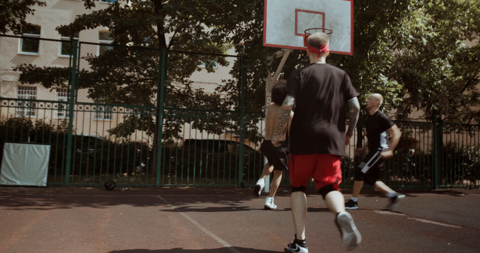

In [15]:
# 검색 결과 메타데이터로 원본 프레임 이미지 표시
from PIL import Image
import os

# 검색 결과 메타데이터를 기반으로 해당 프레임 이미지를 찾아 화면에 표시해주는 함수
def show_image_from_metadata(metadata, frame_dir='frames'):
    video_filename = metadata['video_filename']
    video_basename = os.path.splitext(video_filename)[0] # 확장자 제거
    frame_no = int(metadata['frame_no'])

    image_filename = f'{video_basename}_frame{frame_no:05d}.jpg' # 0 패딩 5자리 포함한 파일명
    image_path = os.path.join(BASE_PATH, frame_dir, video_basename, image_filename) # 완성된 최종 경로

    image = Image.open(image_path)
    image.thumbnail((480,270))
    display(image)

show_image_from_metadata(results[0].metadata)


[1]
야외 농구 코트에서 두 사람이 농구를 하고 있다. 한 명은 공을 드리블하며 이동 중이고, 다른 사람은 뒤에서 수비하는 모습이다. 뒤쪽에는 나무와 철망, 주거 건물, 농구 골대가 보인다.
{'frame_no': 270.0, 'id': '5722520d-ae0d-4802-8879-6096e6cb1e9d', 'video_filename': 'basketball.mp4'}


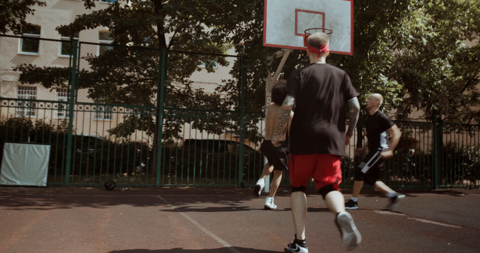

--------------------------------------------------
[2]
실내 축구장에서 등번호 10번 선수가 공을 드리블하며 달리고 있습니다. 뒤쪽에는 골대와 여러 선수들이 보이며, 낮은 앵글과 흔들림 효과로 역동적인 움직임을 강조한 장면입니다.
{'frame_no': 150.0, 'id': 'fd68bee6-ae6d-43a6-bc8d-c6b7a7194848', 'video_filename': 'soccer.mp4'}


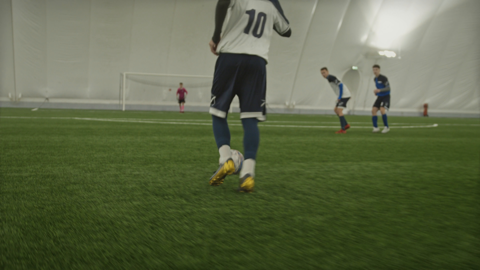

--------------------------------------------------
[3]
야외 농구 코트에서 여러 남성이 농구 경기를 하고 있다. 중앙의 남성은 빨간 머리띠와 빨간 반바지를 착용하고 공을 들고 있으며, 주변 선수들은 수비 자세를 취하고 있다. 배경에는 농구 골대와 철제 펜스, 나무와 건물이 보인다.
{'frame_no': 150.0, 'id': 'cd16bace-8e9e-4a0f-96a3-1742512a5cf6', 'video_filename': 'basketball.mp4'}


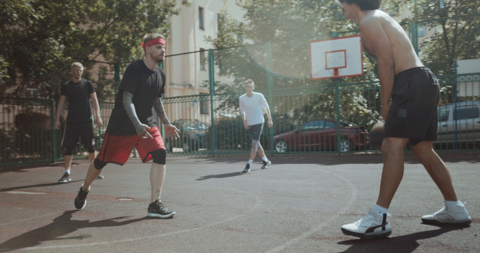

--------------------------------------------------


In [16]:
# 결과 모두 출력
for i, doc in enumerate(results):
  print(f"[{i+1}]")
  print(doc.page_content) # 본문 텍스트
  print(doc.metadata)     # 문서 메타데이터
  show_image_from_metadata(doc.metadata) # 이미지 표시함수
  print('-'*50)